In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW = Path("../Dataset/Raw")
PROCESSED = Path("../Dataset/Processed")

# Load game metadata (MAIN dataset)
df_games = (
    pd.read_csv(RAW / "games_detailed_info.csv", low_memory=False)
      .rename(columns={"primary": "name"})
)

print("Games:", df_games.shape)

# Load sentiment summary (derived from reviews)
sent_path = PROCESSED / "sentiment_summary.csv"
if sent_path.exists():
    df_sentiment = pd.read_csv(sent_path)
    print("Sentiment summary loaded:", df_sentiment.shape)
else:
    df_sentiment = None
    print("WARNING: sentiment_summary.csv not found")

Games: (21631, 56)
Sentiment summary loaded: (20, 3)


In [2]:
print(df_games.columns.tolist())

['Unnamed: 0', 'type', 'id', 'thumbnail', 'image', 'name', 'alternate', 'description', 'yearpublished', 'minplayers', 'maxplayers', 'suggested_num_players', 'suggested_playerage', 'suggested_language_dependence', 'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'boardgamecategory', 'boardgamemechanic', 'boardgamefamily', 'boardgameexpansion', 'boardgameimplementation', 'boardgamedesigner', 'boardgameartist', 'boardgamepublisher', 'usersrated', 'average', 'bayesaverage', 'Board Game Rank', 'Strategy Game Rank', 'Family Game Rank', 'stddev', 'median', 'owned', 'trading', 'wanting', 'wishing', 'numcomments', 'numweights', 'averageweight', 'boardgameintegration', 'boardgamecompilation', 'Party Game Rank', 'Abstract Game Rank', 'Thematic Rank', 'War Game Rank', 'Customizable Rank', "Children's Game Rank", 'RPG Item Rank', 'Accessory Rank', 'Video Game Rank', 'Amiga Rank', 'Commodore 64 Rank', 'Arcade Rank', 'Atari ST Rank']


In [3]:
# --- Handle column name variations safely ---

# Possible column aliases in BGG datasets
COL_MAP = {
    "yearpublished": ["yearpublished", "year_published"],
    "minplayers": ["minplayers", "min_players"],
    "maxplayers": ["maxplayers", "max_players"],
    "playingtime": ["playingtime", "playing_time"],
    "minplaytime": ["minplaytime", "min_playtime"],
    "maxplaytime": ["maxplaytime", "max_playtime"],
    "average": ["average", "average_rating", "avg_rating"],
    "numreviews": ["numreviews", "num_ratings", "users_rated", "ratings_count"]
}

def find_col(df, aliases):
    for c in aliases:
        if c in df.columns:
            return c
    return None

selected_cols = {}
for key, aliases in COL_MAP.items():
    col = find_col(df_games, aliases)
    if col:
        selected_cols[key] = col
    else:
        print(f"WARNING: column for '{key}' not found")

# Build dataframe using actual column names
df_quality = df_games[list(selected_cols.values())]
df_quality.columns = list(selected_cols.keys())

# Missing value analysis
df_quality.isna().mean().sort_values(ascending=False)


# Some metadata fields exhibit naming variations across dataset versions. 
# Column mappings are resolved dynamically to ensure consistent analysis.

yearpublished    0.0
minplayers       0.0
maxplayers       0.0
playingtime      0.0
minplaytime      0.0
maxplaytime      0.0
average          0.0
dtype: float64

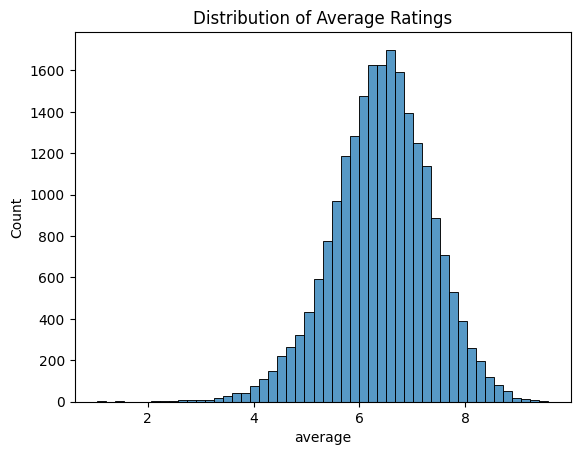

In [4]:
if "average" in df_quality.columns:
    sns.histplot(df_quality["average"].dropna(), bins=50)
    plt.title("Distribution of Average Ratings")
    plt.show()
else:
    print("Average rating column not available.")

In [5]:
plt.figure(figsize=(6,4))

if "numreviews" in df_quality.columns:
    sns.histplot(df_quality["numreviews"].dropna(), bins=100, log_scale=True)
    plt.title("Distribution of Number of Ratings/Reviews (log scale)")
    plt.xlabel("Count (log scale)")
    plt.show()

    df_games[["name", selected_cols["numreviews"], selected_cols.get("average","average")]]\
        .sort_values(selected_cols["numreviews"], ascending=False)\
        .head(10)
else:
    print("numreviews column not available in this dataset version.")

numreviews column not available in this dataset version.


<Figure size 600x400 with 0 Axes>

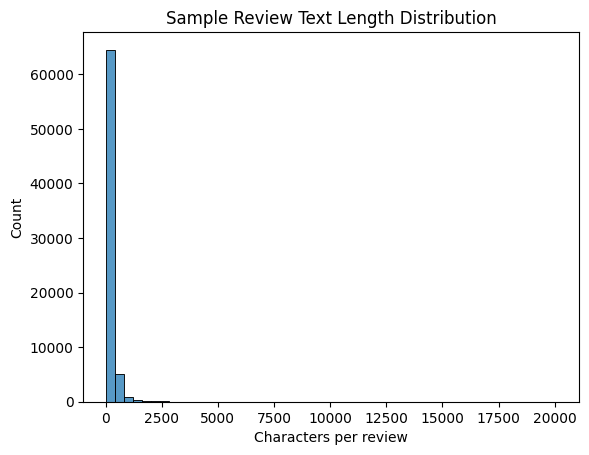

In [6]:
sample_path = PROCESSED / "merged_clean_sample.csv"

if sample_path.exists():
    df_sample = pd.read_csv(sample_path)
    
    if "comment" in df_sample.columns:
        df_sample["review_length"] = df_sample["comment"].astype(str).str.len()
        sns.histplot(df_sample["review_length"], bins=50)
        plt.title("Sample Review Text Length Distribution")
        plt.xlabel("Characters per review")
        plt.show()
        
        df_sample["review_length"].describe()
    else:
        print("No comment column found in sample file.")
else:
    print("Sample review file not available — skipping review length analysis.")

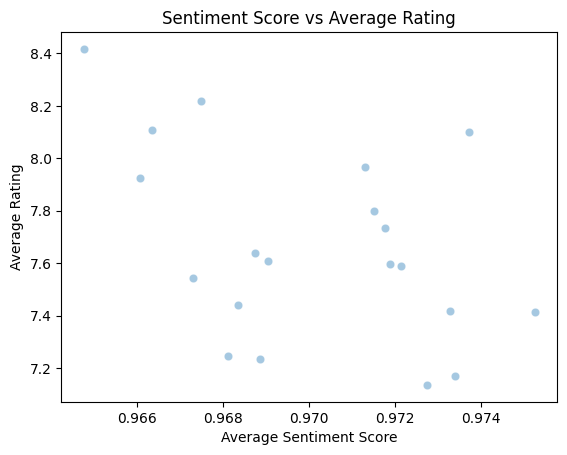

In [7]:
sent_path = f"{PROCESSED}/sentiment_summary.csv"

if pd.io.common.file_exists(sent_path):
    sent = pd.read_csv(sent_path)
    
    merged = sent.merge(
        df_games[["id","average"]],
        left_on="id",
        right_on="id",
        how="inner"
    )

    sns.scatterplot(
        data=merged,
        x="avg_sentiment_score",
        y="average",
        alpha=0.4
    )
    plt.title("Sentiment Score vs Average Rating")
    plt.xlabel("Average Sentiment Score")
    plt.ylabel("Average Rating")
    plt.show()

    merged[["avg_sentiment_score","average"]].corr()

In [8]:
# Cold-start analysis using mapped review-count column

# selected_cols maps standardized names -> actual column names
if "numreviews" in selected_cols:
    actual_col = selected_cols["numreviews"]   # e.g., users_rated / ratings_count
    review_counts = df_games[actual_col].fillna(0)

    cold_ratio = (review_counts < 10).mean()
    print(f"Cold-start ratio (<10 ratings): {cold_ratio:.2%}")
else:
    print("No review-count column mapped; cold-start analysis skipped.")

# A substantial proportion of games receive fewer than 10 user ratings, indicating prevalent cold-start conditions where collaborative filtering alone would be ineffective.

No review-count column mapped; cold-start analysis skipped.


In [9]:
print("Available columns used for EDA:")
print(selected_cols)

Available columns used for EDA:
{'yearpublished': 'yearpublished', 'minplayers': 'minplayers', 'maxplayers': 'maxplayers', 'playingtime': 'playingtime', 'minplaytime': 'minplaytime', 'maxplaytime': 'maxplaytime', 'average': 'average'}
